Name: Tanvi Gajanan Upganlawar

Roll no: 12

PRN no: 1252090012

-------------------------------------------------------------------------------------------------------------------------------------


**ASSIGNMENT 6**

Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following:

a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

b. Bivariate analysis: Linear and logistic regression modeling

c. Multiple Regression analysis

d. Also compare the results of the above analysis for the two data sets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("diabetes.csv")

In [ ]:
print(df.head)

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

In [ ]:
print(df.info)

<bound method DataFrame.info of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   5

Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

In [ ]:
print(df['Outcome'].value_counts())

summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Mode": df.mode().iloc[0],
    "Variance": df.var(),
    "Std Dev": df.std(),
    "Skewness": df.skew(),
    "Kurtosis": df.kurt()
})

print(summary)

Outcome
0    500
1    268
Name: count, dtype: int64
                                Mean    Median    Mode      Variance  \
Pregnancies                 3.845052    3.0000   1.000     11.354056   
Glucose                   120.894531  117.0000  99.000   1022.248314   
BloodPressure              69.105469   72.0000  70.000    374.647271   
SkinThickness              20.536458   23.0000   0.000    254.473245   
Insulin                    79.799479   30.5000   0.000  13281.180078   
BMI                        31.992578   32.0000  32.000     62.159984   
DiabetesPedigreeFunction    0.471876    0.3725   0.254      0.109779   
Age                        33.240885   29.0000  22.000    138.303046   
Outcome                     0.348958    0.0000   0.000      0.227483   

                             Std Dev  Skewness  Kurtosis  
Pregnancies                 3.369578  0.901674  0.159220  
Glucose                    31.972618  0.173754  0.640780  
BloodPressure              19.355807 -1.843608  5.

Linear Regression (Single Feature)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

X = df[['BMI']]
y = df['Glucose']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

print("Coefficient:", lin_model.coef_)
print("Intercept:", lin_model.intercept_)
print("R² Score:", lin_model.score(X_test, y_test))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Coefficient: [0.8642706]
Intercept: 93.2135865493206
R² Score: 0.06707450862298348
MSE: 902.5872390340548
RMSE: 30.04308970518936


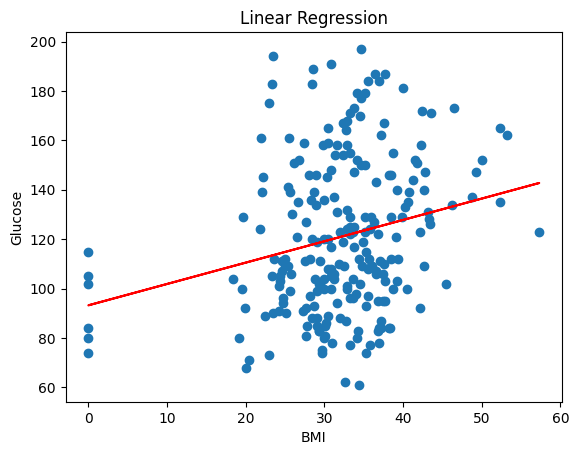

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, lin_model.predict(X_test), color='red')
plt.xlabel("BMI")
plt.ylabel("Glucose")
plt.title("Linear Regression")
plt.show()

Logistic Regression (Single Feature)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7359307359307359
Precision: 0.6172839506172839
Recall: 0.625
F1 Score: 0.6211180124223602
Confusion Matrix:
 [[120  31]
 [ 30  50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



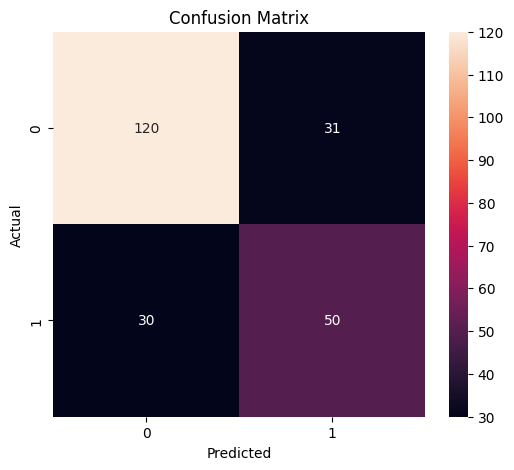

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Linear Regression (Multiple Feature)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df.drop("Glucose", axis=1)

y = df["Glucose"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

multi_lin_model = LinearRegression()
multi_lin_model.fit(X_train, y_train)

y_pred = multi_lin_model.predict(X_test)

print("Intercept:", multi_lin_model.intercept_)
print("Coefficients:", multi_lin_model.coef_)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Intercept: 77.36654878575027
Coefficients: [-0.12267722  0.15245613 -0.37458186  0.09606823  0.29436294  6.91457772
  0.36201688 24.74852858]
R² Score: 0.28280468810375103
MSE: 693.8724929223761
RMSE: 26.341459582232265


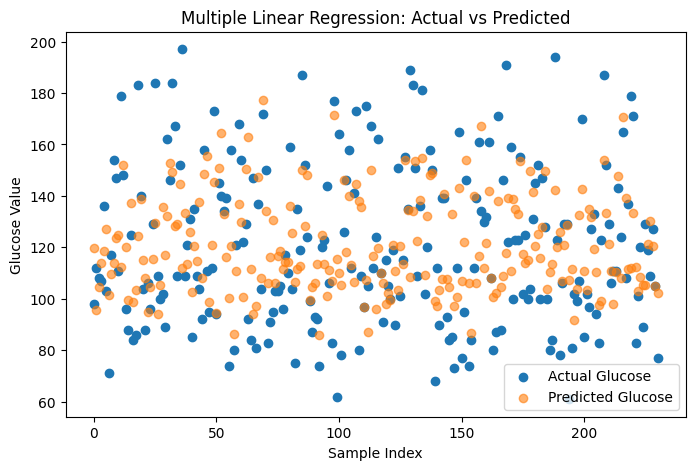

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test, label='Actual Glucose')
plt.scatter(range(len(y_test)), y_pred, alpha=0.6, label='Predicted Glucose')

plt.xlabel("Sample Index")
plt.ylabel("Glucose Value")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.legend()

plt.show()

Logistic Regression (Multiple Features)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

X = df.drop("Outcome", axis=1)

y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

multi_log_model = LogisticRegression(max_iter=1000)
multi_log_model.fit(X_train, y_train)

y_pred = multi_log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7359307359307359
Precision: 0.6172839506172839
Recall: 0.625
F1 Score: 0.6211180124223602

Confusion Matrix:
 [[120  31]
 [ 30  50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



Confusion Matrix:
 [[120  31]
 [ 30  50]]


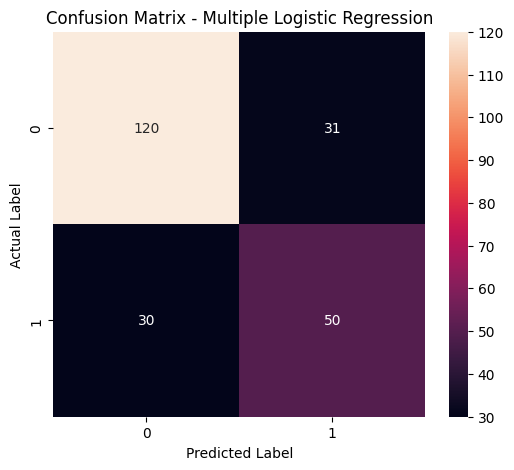

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Multiple Logistic Regression")

plt.show()

sklearn dataset

In [ ]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
sk_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sk_df['target'] = diabetes.target
print("Sklearn Diabetes Shape:", sk_df.shape)
print(sk_df.head())


Sklearn Diabetes Shape: (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [ ]:
print("Mean:\n",sk_df.mean())
print("Median:\n",sk_df.median())
print("Mode:\n",sk_df.mode().loc[0])
print("Variance:\n",sk_df.var())
print("Standard Deviation:\n",sk_df.std())
print("Skewness:\n",sk_df.skew())
print("Kurtosis:\n",sk_df.kurt())

Mean:
 age      -1.444295e-18
sex       2.543215e-18
bmi      -2.255925e-16
bp       -4.854086e-17
s1       -1.428596e-17
s2        3.898811e-17
s3       -6.028360e-18
s4       -1.788100e-17
s5        9.243486e-17
s6        1.351770e-17
target    1.521335e+02
dtype: float64
Median:
 age         0.005383
sex        -0.044642
bmi        -0.007284
bp         -0.005670
s1         -0.004321
s2         -0.003819
s3         -0.006584
s4         -0.002592
s5         -0.001947
s6         -0.001078
target    140.500000
dtype: float64
Mode:
 age        0.016281
sex       -0.044642
bmi       -0.030996
bp        -0.040099
s1        -0.037344
s2        -0.001001
s3        -0.013948
s4        -0.039493
s5        -0.018114
s6         0.003064
target    72.000000
Name: 0, dtype: float64
Variance:
 age          0.002268
sex          0.002268
bmi          0.002268
bp           0.002268
s1           0.002268
s2           0.002268
s3           0.002268
s4           0.002268
s5           0.002268
s6        

Bivariate Linear Regression

In [ ]:
X = sk_df[['bmi']]
y = sk_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Coefficient:",model.coef_)
print("Intercept:",model.intercept_)
print("R2 score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

Coefficient: [988.41931249]
Intercept: 151.04202449316014
R2 score: 0.2803417492440603
MSE: 3884.936720961032
RMSE: 62.32926055201547


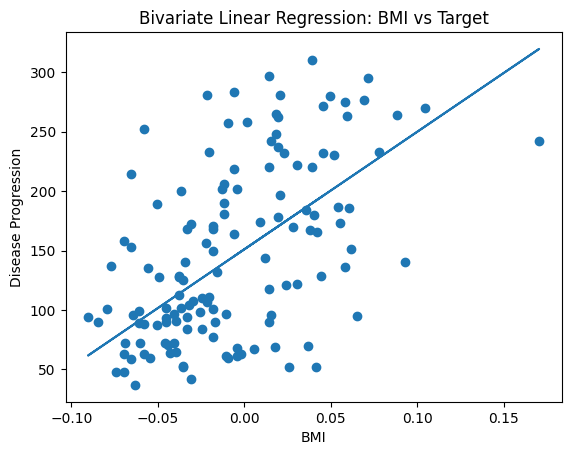

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Bivariate Linear Regression: BMI vs Target")
plt.show()